# Paraphrase Quality Analysis

In the course of this work, we found though achieving low syntactic similarity and high similarity scores (lower right quadrant), many paraphrases were of low quality (e.g., short, model indicating it cannot solve this task, etc.).
We therefore analysed the impact of prompt design on the quality of paraphrases in more detail.

Load paraphrases.
The paraphrases were generated for other experiments, but saved them in a dump for later analysis.

In [ ]:
from genai_detection.visualization.datasets import *
from genai_detection.config import CONFIG
import json
import textwrap

In [98]:
# student essays test
path2json1 = (
    Path(os.getcwd()).resolve().parent
    / CONFIG.SAVE_PATH
    / "impostor_scores/experiments/impostor_generator_comparison/complete_student_essays_test_dataset_1.json"
)

# student essays test for sim syn
path2json2 = (
    Path(os.getcwd()).resolve().parent
    / CONFIG.SAVE_PATH
    / "impostor_scores/experiments/impostor_generator_comparison/student_essays_naive_llm_test_impostor_scores_syn_sim.json"
)

# detection scenarios Student essays
path2json3 = (
    Path(os.getcwd()).resolve().parent
    / CONFIG.SAVE_PATH
    / "impostor_scores/experiments/detection_scenarios/student_essays_naive_llm_test_impostor_scores_detection_scenarios.json"
)

# new prompt
path2newjson = (
    Path(os.getcwd()).resolve().parent
    / CONFIG.SAVE_PATH
    / "dumps/impostor_naive_llm.json"
)

# define dataframes to store results
store_length = pd.DataFrame(
    columns=[
        "paraphraser",
        "prompt",
        "reference_text_length",
        "paraphrase_length",
        "smaller700",
        "reference_pair_id",
        "pair_id",
        "realtive_len_perc",
        "post_process_len_perc(qwen)",
    ]
)
reference_pair_ids = pd.DataFrame(
    columns=["reference_pair_id", "pair_id", "reference_text"]
)
store_garbage_texts = pd.DataFrame(
    columns=["reference_pair_id", "pair_id", "paraphraser", "garbage"]
)
garbage_texts = ["I sorry, but I can't help with that."]

extremest_len_paraphrases = pd.DataFrame(
    columns=[
        "reference_text_length",
        "paraphrase_length",
        "smaller700",
        "paraphraser",
        "reference_pair_id",
        "pair_id",
        "realtive_len_perc",
        "prompt",
        "paraphrase",
    ]
)

extremest_post_processed_len_paraphrases = pd.DataFrame(
    columns=[
        "reference_text_length",
        "paraphrase_length",
        "smaller700",
        "paraphraser",
        "reference_pair_id",
        "pair_id",
        "realtive_len_perc",
        "prompt",
        "paraphrase",
        "post_process_len_perc(qwen)",
    ]
)

perfect_paraphrases = pd.DataFrame(
    columns=[
        "reference_text_length",
        "paraphrase_length",
        "smaller700",
        "paraphraser",
        "reference_pair_id",
        "pair_id",
        "realtive_len_perc",
        "prompt",
        "paraphrase",
        "reference_text",
        "post_process_len_perc(qwen)",
    ]
)


# read json file
for path2json in [path2json1, path2json2, path2json3]:
    print("Reading json file:", path2json)
    with open(path2json, "r", encoding="utf-8") as f:
        df = json.load(f)

    for i in range(len(df)):  # uppermost list level: dictionary
        item = df[i]
        if "artificial_generation" in item and item["artificial_generation"]:
            continue
        if (
            "impostor_dict_naive_llm" not in item
            or item["impostor_dict_naive_llm"] is None
        ):
            continue
        pair_dict = item["impostor_dict_naive_llm"]["text_pair_0"]  # dict with two keys

        for (
            no_in_pair,
            imp_dict,
        ) in pair_dict.items():  # dict containing reference text and paraphrases
            reference_text = imp_dict["reference_text"]
            paraphrases_dict = imp_dict["paraphrases"]
            # calculate word counts (split on whitespace)
            ref_len = len(reference_text.split())

            # add reference text info (ensuring no duplicates)
            reference_pair_ids = pd.concat(
                [
                    reference_pair_ids,
                    pd.DataFrame(
                        [
                            {
                                "reference_pair_id": i,  # position in the outermost list
                                "pair_id": no_in_pair,  # "0" or "1"
                                "reference_text": reference_text,
                            }
                        ]
                    ),
                ],
                ignore_index=True,
            )

            for impostor_name, para in paraphrases_dict.items():  # impostors
                split_name = impostor_name.split("_")
                paraphraser = split_name[-1]
                prompt = split_name[2]

                para_len = len(para.split())
                # check for garbage
                garbage = any(g in para for g in garbage_texts)

                relative_len_perc = np.round((para_len / ref_len) * 100, 2)

                processed_text_len_perc = relative_len_perc
                # qwen3:32b specific post-processing, produces thinking traces
                if "</think>" in para:
                    temp = para.split("</think>")[-1].strip()
                    processed_text_len_perc = np.round(
                        (len(temp.split()) / ref_len) * 100, 2
                    )

                    if processed_text_len_perc > 110 or processed_text_len_perc < 10:
                        extremest_post_processed_len_paraphrases = pd.concat(
                            [
                                extremest_post_processed_len_paraphrases,
                                pd.DataFrame(
                                    [
                                        {
                                            "reference_text_length": ref_len,
                                            "paraphrase_length": para_len,
                                            "smaller700": para_len < 700,
                                            "paraphraser": paraphraser,
                                            "prompt": prompt,
                                            "reference_pair_id": i,  # position in the outermost list
                                            "pair_id": no_in_pair,  # "0" or "1"
                                            "realtive_len_perc": relative_len_perc,
                                            "post_process_len_perc(qwen)": processed_text_len_perc,
                                            "paraphrase": temp,
                                            "reference_text": reference_text,
                                        }
                                    ]
                                ),
                            ],
                            ignore_index=True,
                        )

                # add length info
                store_length = pd.concat(
                    [
                        store_length,
                        pd.DataFrame(
                            [
                                {
                                    "reference_text_length": ref_len,
                                    "paraphrase_length": para_len,
                                    "smaller700": para_len < 700,
                                    "paraphraser": paraphraser,
                                    "prompt": prompt,
                                    "reference_pair_id": i,  # position in the outermost list
                                    "pair_id": no_in_pair,  # "0" or "1"
                                    "realtive_len_perc": relative_len_perc,
                                    "post_process_len_perc(qwen)": processed_text_len_perc,
                                }
                            ]
                        ),
                    ],
                    ignore_index=True,
                )
                if relative_len_perc > 180 or relative_len_perc < 10:
                    extremest_len_paraphrases = pd.concat(
                        [
                            extremest_len_paraphrases,
                            pd.DataFrame(
                                [
                                    {
                                        "reference_text_length": ref_len,
                                        "paraphrase_length": para_len,
                                        "smaller700": para_len < 700,
                                        "paraphraser": paraphraser,
                                        "prompt": prompt,
                                        "reference_pair_id": i,  # position in the outermost list
                                        "pair_id": no_in_pair,  # "0" or "1"
                                        "realtive_len_perc": relative_len_perc,
                                        "paraphrase": para,
                                        "post_process_len_perc(qwen)": processed_text_len_perc,
                                    }
                                ]
                            ),
                        ],
                        ignore_index=True,
                    )
                elif relative_len_perc > 70 and relative_len_perc < 150:
                    perfect_paraphrases = pd.concat(
                        [
                            perfect_paraphrases,
                            pd.DataFrame(
                                [
                                    {
                                        "paraphraser": paraphraser,
                                        "prompt": prompt,
                                        "reference_text_length": ref_len,
                                        "paraphrase_length": para_len,
                                        "smaller700": para_len < 700,
                                        "reference_pair_id": i,  # position in the outermost list
                                        "pair_id": no_in_pair,  # "0" or "1"
                                        "realtive_len_perc": relative_len_perc,
                                        "paraphrase": para,
                                        "reference_text": reference_text,
                                        "post_process_len_perc(qwen)": processed_text_len_perc,
                                    }
                                ]
                            ),
                        ],
                        ignore_index=True,
                    )

                # add garbage info
                store_garbage_texts = pd.concat(
                    [
                        store_garbage_texts,
                        pd.DataFrame(
                            [
                                {
                                    "paraphraser": paraphraser,
                                    "garbage": garbage,
                                    "reference_pair_id": i,  # position in the outermost list
                                    "pair_id": no_in_pair,  # "0" or "1"
                                }
                            ]
                        ),
                    ],
                    ignore_index=True,
                )

# new prompt: json has structure {reference: {impostor_prompt_paraphraser: paraphrase, ...}, ...}
with open(path2newjson, "r", encoding="utf-8") as f:
    df = json.load(f)
for i, (reference_text, para_dict) in enumerate(df.items()):
    ref_len = len(reference_text.split())

    for impostor_name, para in para_dict.items():  # impostors
        split_name = impostor_name.split("_")
        paraphraser = split_name[-1]
        prompt = "_".join(split_name[1:-1])

        para_len = len(para.split())
        # check for garbage
        garbage = any(g in para for g in garbage_texts)

        relative_len_perc = np.round((para_len / ref_len) * 100, 2)

        processed_text_len_perc = relative_len_perc
        temp = para
        if "</think>" in para:
            temp = para.split("</think>")[-1].strip()
            processed_text_len_perc = np.round((len(temp.split()) / ref_len) * 100, 2)

        # add length info
        store_length = pd.concat(
            [
                store_length,
                pd.DataFrame(
                    [
                        {
                            "reference_text_length": ref_len,
                            "paraphrase_length": para_len,
                            "smaller700": para_len < 700,
                            "paraphraser": paraphraser,
                            "prompt": "prompt2",
                            "reference_pair_id": i,  # position in the outermost list
                            "pair_id": 0,  # "0" or "1"
                            "realtive_len_perc": relative_len_perc,
                            "post_process_len_perc(qwen)": processed_text_len_perc,
                        }
                    ]
                ),
            ],
            ignore_index=True,
        )
        if processed_text_len_perc > 200 or processed_text_len_perc < 10:
            extremest_post_processed_len_paraphrases = pd.concat(
                [
                    extremest_post_processed_len_paraphrases,
                    pd.DataFrame(
                        [
                            {
                                "reference_text_length": ref_len,
                                "paraphrase_length": para_len,
                                "smaller700": para_len < 700,
                                "paraphraser": paraphraser,
                                "prompt": "prompt2",
                                "reference_pair_id": i,  # position in the outermost list
                                "pair_id": 0,  # "0" or "1"
                                "realtive_len_perc": relative_len_perc,
                                "post_process_len_perc(qwen)": processed_text_len_perc,
                                "paraphrase": temp,
                                "reference_text": reference_text,
                            }
                        ]
                    ),
                ],
                ignore_index=True,
            )
        elif processed_text_len_perc > 90 and processed_text_len_perc < 110:
            perfect_paraphrases = pd.concat(
                [
                    perfect_paraphrases,
                    pd.DataFrame(
                        [
                            {
                                "paraphraser": paraphraser,
                                "prompt": "prompt2",
                                "reference_text_length": ref_len,
                                "paraphrase_length": para_len,
                                "smaller700": para_len < 700,
                                "reference_pair_id": i,  # position in the outermost list
                                "pair_id": 0,  # "0" or "1"
                                "realtive_len_perc": processed_text_len_perc,
                                "paraphrase": temp,
                                "reference_text": reference_text,
                            }
                        ]
                    ),
                ],
                ignore_index=True,
            )


display(store_length)
# display(store_garbage_texts)
# display(reference_pair_ids)
print("Number of garbage texts:", store_garbage_texts["garbage"].sum())

Reading json file: /Users/klara/Developer/Uni/MA/artificial-authorship-verification/results/impostor_scores/experiments/impostor_generator_comparison/complete_student_essays_test_dataset_1.json


/var/folders/hk/dwphr0p14vn00wrnlw8bxjpw0000gn/T/ipykernel_1936/629071375.py:185: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  store_length = pd.concat(
/var/folders/hk/dwphr0p14vn00wrnlw8bxjpw0000gn/T/ipykernel_1936/629071375.py:207: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  extremest_len_paraphrases = pd.concat(
/var/folders/hk/dwphr0p14vn00wrnlw8bxjpw0000gn/T/ipykernel_1936/629071375.py:160: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated

Reading json file: /Users/klara/Developer/Uni/MA/artificial-authorship-verification/results/impostor_scores/experiments/impostor_generator_comparison/student_essays_naive_llm_test_impostor_scores_syn_sim.json
Reading json file: /Users/klara/Developer/Uni/MA/artificial-authorship-verification/results/impostor_scores/experiments/detection_scenarios/student_essays_naive_llm_test_impostor_scores_detection_scenarios.json


,paraphraser,prompt,reference_text_length,paraphrase_length,smaller700,reference_pair_id,pair_id,realtive_len_perc,post_process_len_perc(qwen)
0,mistral-large-instruct,prompt0,794,22,True,0,0,2.77,2.77
1,mistral-large-instruct,prompt1,794,242,True,0,0,30.48,30.48
2,meta-llama-3.1-8b-instruct,prompt0,794,127,True,0,0,15.99,15.99
3,meta-llama-3.1-8b-instruct,prompt1,794,175,True,0,0,22.04,22.04
4,openai-gpt-oss-120b,prompt0,794,8,True,0,0,1.01,1.01
...,...,...,...,...,...,...,...,...,...
3256,mistral-large-instruct,prompt2,918,665,True,45,0,72.44,72.44
3257,openai-gpt-oss-120b,prompt2,918,1159,False,45,0,126.25,126.25
3258,qwen3-32b,prompt2,918,853,False,45,0,92.92,92.92
3259,meta-llama-3.1-8b-instruct,prompt2,918,824,False,45,0,89.76,89.76


Number of garbage texts: 0


Visualize the impact of prompt design on paraphrase length.

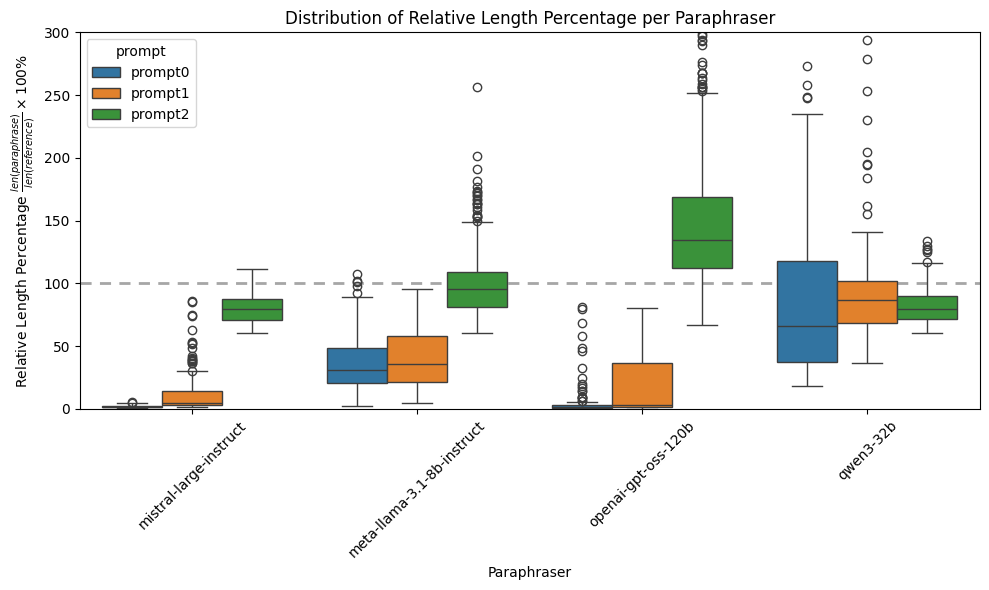

/var/folders/hk/dwphr0p14vn00wrnlw8bxjpw0000gn/T/ipykernel_1936/1760603986.py:30: UserWarning: Attempt to set non-positive ylim on a log-scaled axis will be ignored.
  plt.ylim(0, 300)


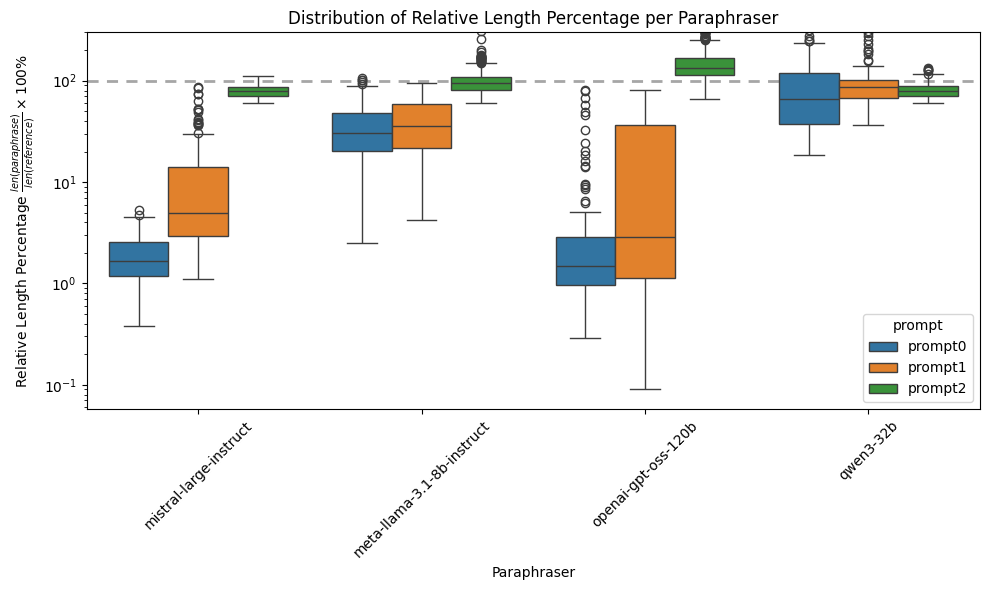

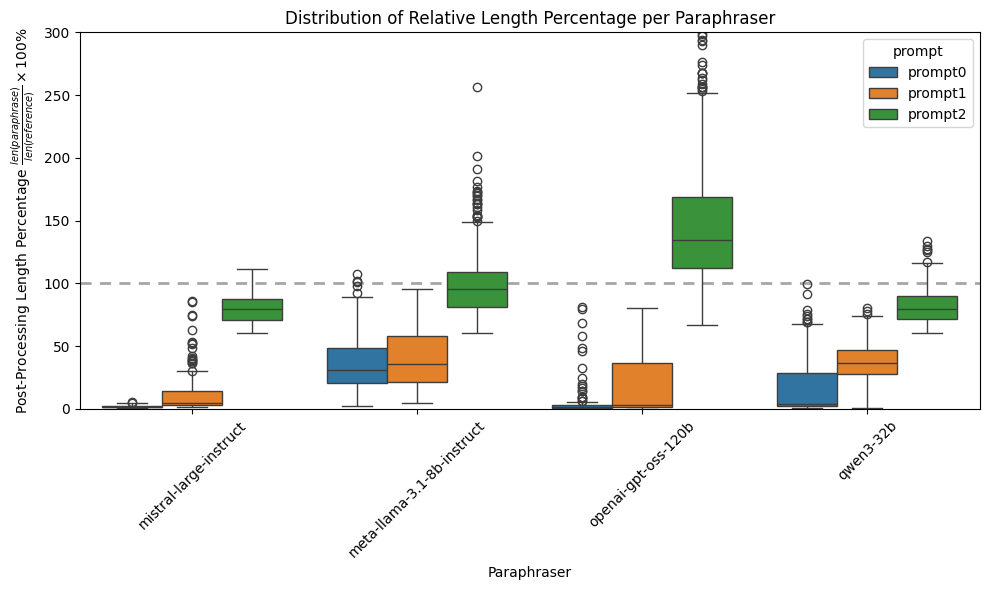

/var/folders/hk/dwphr0p14vn00wrnlw8bxjpw0000gn/T/ipykernel_1936/1760603986.py:30: UserWarning: Attempt to set non-positive ylim on a log-scaled axis will be ignored.
  plt.ylim(0, 300)


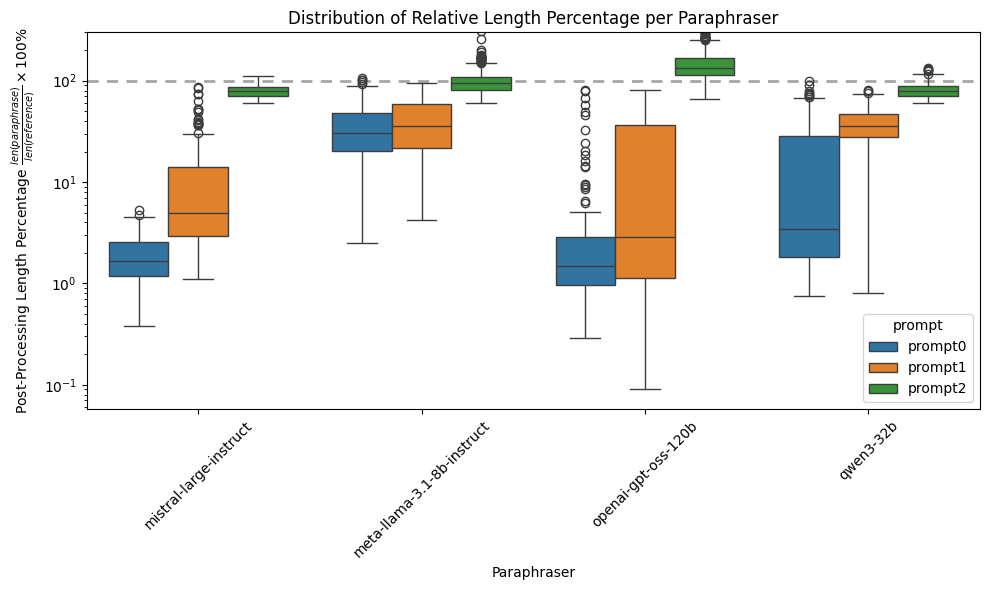

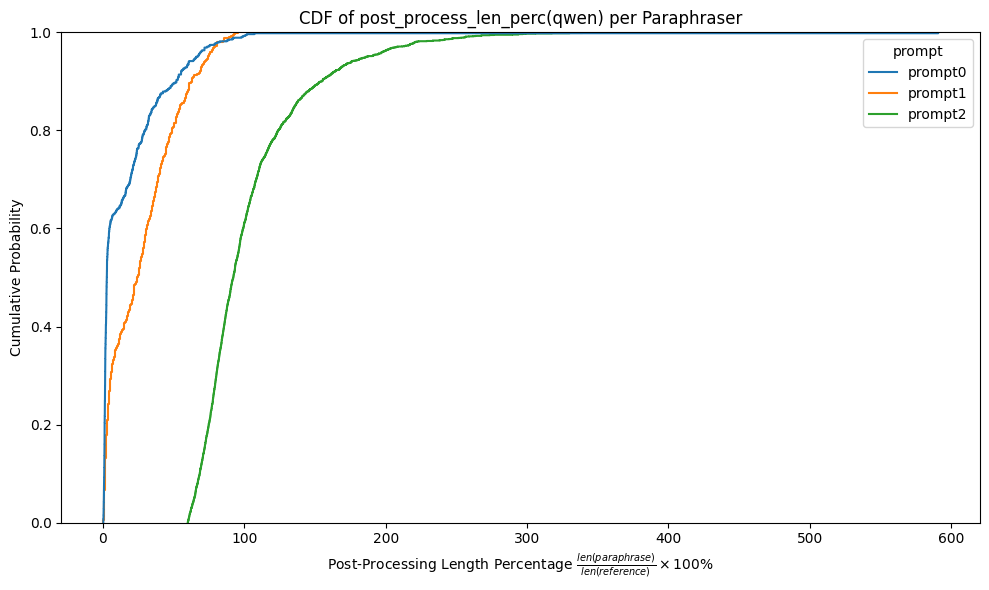

In [99]:
import seaborn as sns
import matplotlib.pyplot as plt


save_path = Path(os.getcwd()).resolve().parent / CONFIG.SAVE_PATH / "prompt_impact"
save_path.mkdir(parents=True, exist_ok=True)
for y_col in [
    "realtive_len_perc",
    "post_process_len_perc(qwen)",
]:
    for scale in ["linear", "log"]:
        plt.figure(figsize=(10, 6))
        sns.boxplot(x="paraphraser", y=y_col, data=store_length, hue="prompt")

        # Add horizontal reference line at y=100
        plt.axhline(
            y=100, color="gray", linestyle=(0, (4, 3)), alpha=0.7, zorder=0, linewidth=2
        )

        if scale == "log":
            plt.yscale("log")  # log scale to expand lower region
        plt.title(f"Distribution of Relative Length Percentage per Paraphraser")
        plt.xlabel("Paraphraser")
        plt.ylabel(
            r"Relative Length Percentage $\frac{len(paraphrase)}{len(reference)}\times 100\%$"
            if y_col == "realtive_len_perc"
            else r"Post-Processing Length Percentage $\frac{len(paraphrase)}{len(reference)}\times 100\%$"
        )
        plt.xticks(rotation=45)
        plt.ylim(0, 300)
        plt.tight_layout()
        plt.savefig(
            save_path / f"paraphraser_length_distribution_{y_col}_{scale}.svg",
            dpi=300,
            bbox_inches="tight",
        )
        plt.show()
        plt.close()


plt.figure(figsize=(10, 6))
sns.ecdfplot(
    data=store_length,
    x="post_process_len_perc(qwen)",
    hue="prompt",
    # col="paraphraser",  # facet by paraphraser
)
plt.title(f"CDF of post_process_len_perc(qwen) per Paraphraser")
plt.xlabel(
    r"Relative Length Percentage $\frac{len(paraphrase)}{len(reference)}\times 100\%$"
    if y_col == "realtive_len_perc"
    else r"Post-Processing Length Percentage $\frac{len(paraphrase)}{len(reference)}\times 100\%$"
)
plt.ylabel("Cumulative Probability")
plt.tight_layout()
plt.show()
plt.close()

Store results in dataframe.

In [100]:
import numpy as np

gt_store_length = (
    store_length[
        ["paraphraser", "prompt", "realtive_len_perc", "post_process_len_perc(qwen)"]
    ]
    .groupby(["paraphraser", "prompt"])
    .agg(
        mean_relative_len_perc=("realtive_len_perc", "mean"),
        std_relative_len_perc=("realtive_len_perc", "std"),
        mean_processed_qwen=("post_process_len_perc(qwen)", "mean"),
        std_processed_qwen=("post_process_len_perc(qwen)", "std"),
        count=("realtive_len_perc", "size"),
    )
    .reset_index()
)

# round floats for readability
gt_store_length = gt_store_length.applymap(
    lambda x: np.round(x, 2) if isinstance(x, float) else x
)
gt_store_length.to_csv(save_path / "impact_prompt.csv", index=False)
gt_store_length

/var/folders/hk/dwphr0p14vn00wrnlw8bxjpw0000gn/T/ipykernel_1936/2784438351.py:19: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  gt_store_length = gt_store_length.applymap(


,paraphraser,prompt,mean_relative_len_perc,std_relative_len_perc,mean_processed_qwen,std_processed_qwen,count
0,meta-llama-3.1-8b-instruct,prompt0,39.93,52.64,39.93,52.64,135
1,meta-llama-3.1-8b-instruct,prompt1,40.27,24.21,40.27,24.21,124
2,meta-llama-3.1-8b-instruct,prompt2,98.15,24.97,98.15,24.97,639
3,mistral-large-instruct,prompt0,1.89,1.00,1.89,1.00,138
4,mistral-large-instruct,prompt1,13.09,17.96,13.09,17.96,129
5,mistral-large-instruct,prompt2,79.70,11.40,79.70,11.40,449
6,openai-gpt-oss-120b,prompt0,5.53,13.47,5.53,13.47,139
7,openai-gpt-oss-120b,prompt1,19.21,25.00,19.21,25.00,129
8,openai-gpt-oss-120b,prompt2,147.54,48.45,147.54,48.45,590
9,qwen3-32b,prompt0,88.36,70.02,18.68,24.09,134


Relative length is computed as $\frac{len(paraphrase)}{len(reference)}\times 100\%$.

```python
(para_len / ref_len) * 100
```
Hence, a relative length of 100% means that the paraphrase has the same length as the reference. 
A relative length of 50% means that the paraphrase is half as long as the reference, and a relative length of 200% means that the paraphrase is twice as long as the reference.

_Count_ denotes the number of samples considered for the statistics.

We computed mean and standard deviation of the relative lengths per paraphraser and prompt.
All statistics are computed on samples from the Student Essay dataset (where candidates and disputed texts are authored by humans).

The qwen related measures/ columns differ for `qwen3-32b`since we found a pattern in generated text which we filtered out resulting in valid paraphrases which are way shorter than the original paraphrase (which contained chain-of-thought).

In [101]:
save_path = (
    Path(os.getcwd()).resolve().parent
    / CONFIG.SAVE_PATH
    / "post_hoc_paraphrase_analysis"
)
save_path.mkdir(parents=True, exist_ok=True)
gt_store_length.to_csv(
    save_path / "relative_length_perc_per_paraphraser_prompt.csv", index=False
)
print("Saved to", save_path / "relative_length_perc_per_paraphraser_prompt.csv")

Saved to /Users/klara/Developer/Uni/MA/artificial-authorship-verification/results/post_hoc_paraphrase_analysis/relative_length_perc_per_paraphraser_prompt.csv


Are the longest `qwen3-32b` paraphrases of low quality?

Yes, they contain the step-by-step process of replacing words with synonyms.

In [102]:
qwen_extremes = extremest_len_paraphrases[
    extremest_len_paraphrases["paraphraser"] == "qwen3-32b"
]
print("Number of long qwen3-32b paraphrases:", len(qwen_extremes))
print(qwen_extremes.columns)

top_qwen = qwen_extremes.sort_values(by="paraphrase_length", ascending=False)[
    ["paraphrase", "paraphrase_length"]
].head(5)

for _, row in top_qwen.iterrows():
    p = row["paraphrase"]
    l = row["paraphrase_length"]

    # show first and last 100 characters
    print("Number of words:", l)
    print(
        textwrap.fill(p[:100], width=80), "...\n...", textwrap.fill(p[-100:], width=80)
    )
    print("-" * 80)

Number of long qwen3-32b paraphrases: 22
Index(['reference_text_length', 'paraphrase_length', 'smaller700',
       'paraphraser', 'reference_pair_id', 'pair_id', 'realtive_len_perc',
       'prompt', 'paraphrase', 'post_process_len_perc(qwen)'],
      dtype='object')
Number of words: 3950
<think> Okay, let's tackle this. The user wants me to paraphrase the given text
by identifying the m ...
... n grammar. I’m not very skilled in that area, haha, but it’s crucial when
learning a language. Done.
--------------------------------------------------------------------------------
Number of words: 3382
<think> Okay, let's start by reading the original text carefully. The user wants
me to paraphrase th ...
... earn Spanish as needed. Really worried. I want to, but what if I can’t? Staying
positive is so hard.
--------------------------------------------------------------------------------
Number of words: 3094
<think> Okay, let's tackle this. The user wants me to paraphrase a given
sentence by

Are perfect paraphrases (in terms of length) of low quality? (un-/comment prompt2)
We use this as a heuristic for paraphrases of similar length as the reference.

4 out of 5 perfect paraphrases (in terms of length) generated by `qwen3-32b` include a `</think>`.
Before this sign all text is chain-of-thought explaining how to replace words with synonyms.
After this sign the actual paraphrase starts.

In [103]:
qwen_perfects = perfect_paraphrases[(perfect_paraphrases["prompt"] != "prompt2")]
print("Number of perfect length paraphrases:", len(qwen_perfects))

top_qwen = qwen_perfects[["paraphrase", "paraphrase_length"]].head(5)

for _, row in top_qwen.iterrows():
    p = row["paraphrase"]
    l = row["paraphrase_length"]

    # show first and last 100 characters
    print("Number of words:", l)
    print(
        textwrap.fill(p[:100], width=80), "...\n...", textwrap.fill(p[-100:], width=80)
    )
    print("-" * 80)
    print()

Number of perfect length paraphrases: 170
Number of words: 900
<think> Okay, let's see. The user wants me to paraphrase a given sentence by
identifying the main su ...
... sentence, so that's the one. </think>  Ann committed her initial award-winning
publication to Betty.
--------------------------------------------------------------------------------

Number of words: 537
<think> Okay, let me tackle this. The user wants a paraphrased version of the
provided text without ...
... ing depression at the University of Pittsburgh, and later dedicated her award-
winning book to Betty.
--------------------------------------------------------------------------------

Number of words: 552
<think> Okay, let's start by reading through the original text to understand the
key points. Betty i ...
... row, driven by the thrill of scientific exploration and her place among
respected female scientists.
--------------------------------------------------------------------------------

Number of words: 85

Try omitting `</think>` and the text before it from the paraphrase.

In [104]:
import textwrap

# Post-process the paraphrase text
qwen_perfects["post_processed_text"] = qwen_perfects.apply(
    lambda row: (
        row["paraphrase"].split("</think>")[-1].strip()
        if "</think>" in row["paraphrase"]
        else row["paraphrase"]
    ),
    axis=1,
)

# Select top 5 by length (or just first 5 rows)
top_qwen = qwen_perfects[["post_processed_text", "paraphrase_length"]].head(5)

for _, row in top_qwen.iterrows():
    p = row["post_processed_text"]
    l = len(p.split())

    print(
        "Number of words before/ after processing:", row["paraphrase_length"], " / ", l
    )
    print("-" * 80)
    # wrap full text every 80 characters
    print(textwrap.fill(p, width=80))
    print("=" * 80)
    print("=" * 80)

Number of words before/ after processing: 900  /  8
--------------------------------------------------------------------------------
Ann committed her initial award-winning publication to Betty.
Number of words before/ after processing: 537  /  312
--------------------------------------------------------------------------------
These women have spent years striving to reach their current positions. Betty,
the one in the background, and Ann, the one in the foreground, have both
dedicated themselves to becoming respected female scientists. Betty famously
pressured Harvard’s school board to grant her a science degree, making her a
pioneer in vaccination research. Their era, around World War II, placed them
ahead of their time. Ann, being younger, faced fewer barriers in her education,
thanks in part to trailblazers like Betty. With their husbands supporting the
war effort overseas, the women focused on combating smallpox, a disease
afflicting returning soldiers. Working in a New York lab,

/var/folders/hk/dwphr0p14vn00wrnlw8bxjpw0000gn/T/ipykernel_1936/3848094270.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  qwen_perfects["post_processed_text"] = qwen_perfects.apply(


Are long and short processed prompts paraphrases for *prompt 1* and *prompt 2* good? (numbered 0 and 1 in the plots and data frames)

They are okay in terms of content but way too short!

In [105]:
processed_extremes = extremest_post_processed_len_paraphrases[
    (extremest_post_processed_len_paraphrases["prompt"] != "prompt2")
]
print("Number of short/ long paraphrases:", len(processed_extremes))

shortest_non_prompt2 = processed_extremes.sort_values(
    by="post_process_len_perc(qwen)", ascending=True
)[["paraphrase", "post_process_len_perc(qwen)"]].head(5)

longest_non_prompt2 = processed_extremes.sort_values(
    by="post_process_len_perc(qwen)", ascending=False
)[["paraphrase", "post_process_len_perc(qwen)"]].head(5)

for extremest in [shortest_non_prompt2, longest_non_prompt2]:
    for _, row in extremest.iterrows():
        p = row["paraphrase"]
        l = row["post_process_len_perc(qwen)"]

        # show first and last 100 characters
        print("Number of words:", len(p.split()))
        print(textwrap.fill(p, width=80))

Number of short/ long paraphrases: 83
Number of words: 8
I feel a bit silly at the moment.
Number of words: 6
I will not repeat this error.
Number of words: 9
I'm currently feeling somewhat swamped by my academic workload.
Number of words: 8
The woman desired to become slender and attractive.
Number of words: 11
I’m currently experiencing worry due to my mother and academic performance.
Number of words: 57
Maddie realized she was on the verge of a monumental scientific discovery, one
that could upend existing theories and shake the academic world, yet the ticking
clock and Sarah’s anxious gaze threatened to derail her focus as they secretly
toiled in the lab, determined to succeed despite the risks, until the husband’s
unexpected return revealed their triumph.
Number of words: 70
I am seated here contemplating that I had a subject to write about but instead I
have this. my thoughts. me. well to start it off my roommates in my living room
are blasting the tv and I am reluctant to ask th

Explore *prompt 3* paraphrases.
We look at the closest to 100% relative length for any LLM.

In [106]:
closest_to_100 = (
    perfect_paraphrases.loc[perfect_paraphrases["prompt"] == "prompt2"]
    .assign(abs_diff=lambda df: (df["post_process_len_perc(qwen)"] - 100).abs())
    .sort_values("abs_diff")
)
print("Number of perfect paraphrases:", len(closest_to_100))

top = closest_to_100[["paraphrase", "paraphrase_length", "reference_text"]].head(5)

for _, row in top.iterrows():
    p = row["paraphrase"]
    l = row["paraphrase_length"]
    o = row["reference_text"]

    # show first and last 100 characters
    print("ORIGINAL")
    # print(
    #     textwrap.fill(o[:400], width=80), "...\n...", textwrap.fill(o[-400:], width=80)
    # )
    print(textwrap.fill(o, width=80))
    print("PARAPHRASE. Number of words:", l)
    # print(
    #     textwrap.fill(p[:400], width=80), "...\n...", textwrap.fill(p[-400:], width=80)
    # )
    print("PARAPHRASE: ", textwrap.fill(p, width=80))
    print("-" * 80)
    print()

Number of perfect paraphrases: 550
ORIGINAL
One day the girl walked into her high school chemistry class and the teaher
announced "today we are going to do an experiment, please pair up!" The girl
went and sat down at her seat and patiently waited for her usual lab partner to
show up, while everyone else was pairing off. She waited until the bell rang,
and then she realized that her lab partner did not come to school that day! Once
she realized this she desperately searched for someone else to work with, but it
was too late everyone else had already paired up. She was left to work by
herself, and chemistry had never been her strong suit. She sat nervously and
waited for the teacher to give the next intructions. This particular teacher was
not what anyone would call nice. She was not particularly loving, friendly, or
understanding. She was the first to yell at the students and make them cry, and
she never held back on her criticism. And this made the girl even more
aprehensive about wor

We look at the extremest (long and short) paraphrases for *prompt 3*.

In [107]:
processed_extremes = extremest_post_processed_len_paraphrases[
    (extremest_post_processed_len_paraphrases["prompt"] == "prompt2")
]
print("Number of long/short paraphrases:", len(processed_extremes))
print(processed_extremes.columns)
top_extremes = processed_extremes.sort_values(
    by="post_process_len_perc(qwen)", ascending=False
)[["paraphrase", "post_process_len_perc(qwen)", "reference_text"]]
if len(top_extremes) >= 4:
    top_extremes = top_extremes.iloc[[0, 1, -2, -1]]

for _, row in top_extremes.iterrows():
    p = row["paraphrase"]
    l = row["post_process_len_perc(qwen)"]
    o = row["reference_text"]

    # show first and last 100 characters
    print("Number of words/ processed relative to reference:", len(p.split()), "/", l)
    print("ORIGINAL")
    # print(
    #     textwrap.fill(o[:400], width=80), "...\n...", textwrap.fill(o[-400:], width=80)
    # )
    print(textwrap.fill(o, width=80))
    print("PARAPHRASE. Number of words:", l)
    # print(
    #     textwrap.fill(p[:400], width=80), "...\n...", textwrap.fill(p[-400:], width=80)
    # )
    print("PARAPHRASE: ", textwrap.fill(p, width=80))
    print("==" * 80)
    print()

Number of long/short paraphrases: 83
Index(['reference_text_length', 'paraphrase_length', 'smaller700',
       'paraphraser', 'reference_pair_id', 'pair_id', 'realtive_len_perc',
       'prompt', 'paraphrase', 'post_process_len_perc(qwen)',
       'reference_text'],
      dtype='object')
Number of words/ processed relative to reference: 3548 / 506.86
ORIGINAL
It feels weird to start writing again. I haven't been writing very much lately.
It feels like I haven't been breathing very much lately. I don't know why I
stopped writing. I just felt blocked, I guess. I'm trying to get over it, but
the longer I go without writing, the harder it is to start again. I was writing
a novel. I had something to say. But then everything changed and fell apart and
it seemed like what I was saying was just so trivial and maybe it wasn't worth
saying after all. It's hard to throw all your passions into getting a message
out when you're not really sure of that message yourself. Maybe I'm not writing
because